In [3]:
print('Data analysis & visualization')

Data analysis & visualization


In [5]:
import pandas as pd

In [8]:
data = {'Name': ['Alice', 'Bob'], 'Age': [25, 30]}
df = pd.DataFrame(data)
df

,Name,Age
0,Alice,25
1,Bob,30


In [11]:
print('Eval function')

Eval function


In [10]:
x = 10
result = eval('x * 3 + 5')
print(result)  
print(eval('2 + 3 * 4'))  


35
14


In [12]:
radius = 7
pi = 3.14
area = eval('pi * radius ** 2')
print(f"Circle area: {area}")  


Circle area: 153.86


In [25]:
user_input = "__import__('os').system('notepad.exe')"
eval(user_input)  

0

In [21]:
try:
    eval('2 + + 3')      # SyntaxError
    eval('abc * 10')     # NameError (abc undefined)
except SyntaxError:
    print("Invalid syntax!")
except NameError:
    print("Variable missing!")


Variable missing!


In [26]:
from ast import literal_eval

config = "{'name': 'Yash', 'skills': ['Python', 'SQL']}"
data = literal_eval(config)
print(data['skills'])  



['Python', 'SQL']


In [28]:
print('isinstance')

isinstance


In [29]:
num = 42
text = "hello"
print(isinstance(num, int))    # True
print(isinstance(text, str))   # True
print(isinstance(num, str))    # False


True
True
False


In [32]:
data = ["apple", "banana"]

if isinstance(data, list):
    print("list ")
elif isinstance(data, str):
    print("string ")
else:
    print("nothing")

if isinstance(data, (list, str)):
    print("List or String !")  


list 
List or String !


In [33]:
def process_data(item):
    if isinstance(item, (int, float)):
        return item * 2
    elif isinstance(item, (list, tuple)):
        return [x*2 for x in item]
    elif isinstance(item, str):
        return item.upper()
    else:
        return item

print(process_data(5))        # 10
print(process_data([1,2,3]))  # [2,4,6]
print(process_data("hi"))     # "HI"


10
[2, 4, 6]
HI


In [34]:
class DataProcessor:
    def __init__(self):
        self.errors = []
    
    def validate_and_process(self, data):
        """Mixed data को safely process करता है"""
        if isinstance(data, dict):
            return self.process_dict(data)
        elif isinstance(data, (list, tuple)):
            return [self.validate_and_process(item) for item in data]
        elif isinstance(data, str):
            return data.strip().upper()
        elif isinstance(data, (int, float)):
            return float(data)
        else:
            self.errors.append(f"Invalid type: {type(data)}")
            return None
    
    def process_dict(self, data):
        result = {}
        for key, value in data.items():
            if isinstance(key, str):
                result[key] = self.validate_and_process(value)
        return result

# Usage Example (API response जैसा)
api_data = {
    "name": "Yash",
    "age": "22",
    "scores": [85, "90", 78.5],
    "active": True
}

processor = DataProcessor()
clean_data = processor.validate_and_process(api_data)
print(clean_data)


{'name': 'YASH', 'age': '22', 'scores': [85.0, '90', 78.5], 'active': 1.0}


In [35]:
import csv

def safe_csv_reader(file_path):
    with open(file_path, 'r') as file:
        reader = csv.DictReader(file)
        for row in reader:
            processed_row = {}
            for key, value in row.items():
                if isinstance(value, str) and value.isdigit():
                    processed_row[key] = int(value)
                elif isinstance(value, str):
                    processed_row[key] = value.strip()
                else:
                    processed_row[key] = value
            yield processed_row


In [36]:
mixed_data = ["apple", 123, [1,2], {"key": "value"}]

for item in mixed_data:
    print(f"{item}: {type(item).__name__}")
    if isinstance(item, str):
        print(f"  → Length: {len(item)}")
    elif isinstance(item, (int, float)):
        print(f"  → Double: {item * 2}")
    else:
        print("  → Container - process children")


apple: str
  → Length: 5
123: int
  → Double: 246
[1, 2]: list
  → Container - process children
{'key': 'value'}: dict
  → Container - process children


In [37]:
print('K Mean')

K Mean


In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

data = {
    'Annual_Income': [15, 16, 17, 18, 19, 20, 21, 24, 25, 29, 39, 45, 57, 63, 70],
    'Spending_Score': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72, 14, 99, 15, 77, 13]
}
df = pd.DataFrame(data)
df

,Annual_Income,Spending_Score
0,15,39
1,16,81
2,17,6
3,18,77
4,19,40
5,20,76
6,21,6
7,24,94
8,25,3
9,29,72


C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

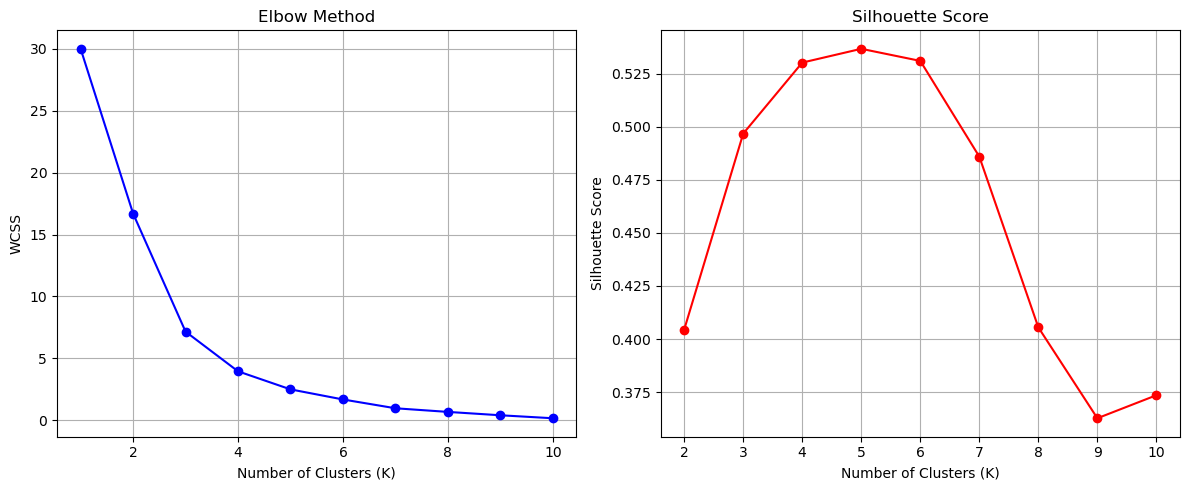

In [40]:
wcss = []
silhouette_scores = []
K_range = range(1, 11)

for k in K_range:
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    
    if k > 1:
        silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

# Plot Elbow Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(K_range[1:], silhouette_scores, 'ro-')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid()
plt.tight_layout()
plt.show()


In [42]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Results
df['Cluster'] = clusters
df


C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Annual_Income,Spending_Score,Cluster
0,15,39,2
1,16,81,0
2,17,6,2
3,18,77,0
4,19,40,2
5,20,76,0
6,21,6,2
7,24,94,0
8,25,3,2
9,29,72,0


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "data science python machine learning",
    "sql database analytics business intelligence", 
    "python pandas numpy data visualization",
    "machine learning ai deep learning neural networks",
    "sql queries joins data warehouse etl"
]

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)

kmeans_text = KMeans(n_clusters=2, random_state=42, n_init=10)
text_clusters = kmeans_text.fit_predict(tfidf_matrix)

print("Text Clusters:", text_clusters)


Text Clusters: [0 1 0 0 1]


C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


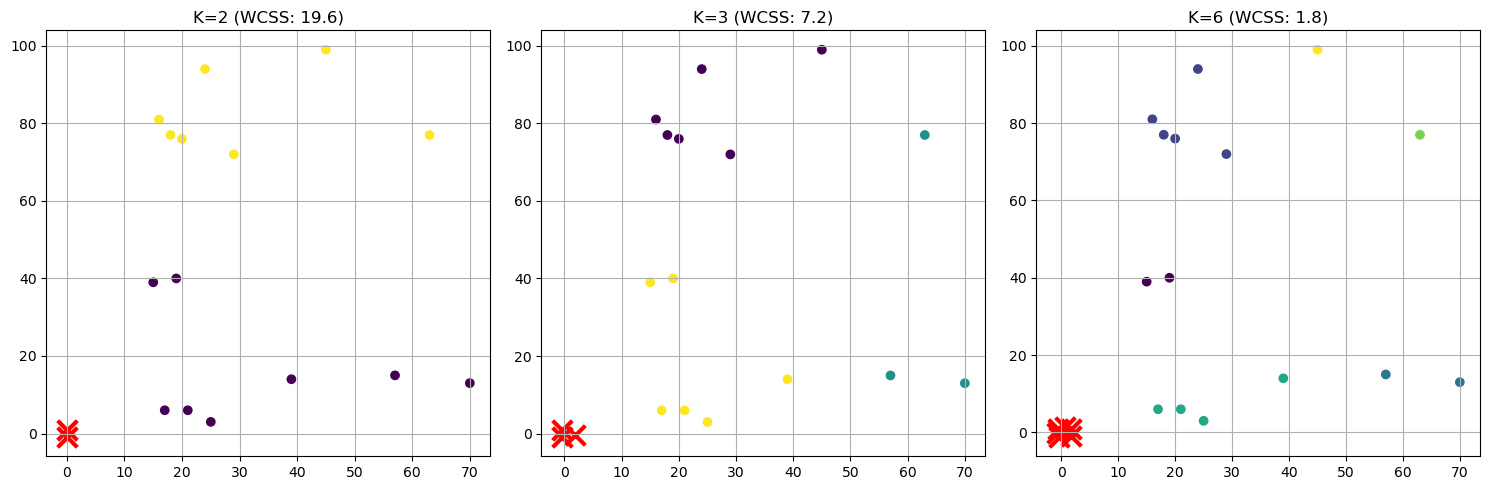

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, k in enumerate([2, 3, 6]):  # Wrong, Good, Too High
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_temp = kmeans_temp.fit_predict(scaled_data)
    
    axes[i].scatter(df['Annual_Income'], df['Spending_Score'], 
                   c=clusters_temp, cmap='viridis')
    axes[i].scatter(kmeans_temp.cluster_centers_[:,0], 
                   kmeans_temp.cluster_centers_[:,1], 
                   c='red', marker='x', s=200, linewidth=3)
    axes[i].set_title(f'K={k} (WCSS: {kmeans_temp.inertia_:.1f})')
    axes[i].grid()

plt.tight_layout()
plt.show()


In [46]:
class CustomerSegmenter:
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
    
    def find_best_k(self, data, max_k=10):
        """Elbow method automatically"""
        wcss = []
        for k in range(1, max_k+1):
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(self.scaler.fit_transform(data))
            wcss.append(kmeans.inertia_)
        
        # Elbow point detect
        deltas = np.diff(wcss)
        best_k = np.argmin(deltas[1:] / deltas[:-1]) + 2
        return best_k
    
    def segment_customers(self, data):
        best_k = self.find_best_k(data)
        print(f"Best K: {best_k}")
        
        scaled_data = self.scaler.fit_transform(data)
        self.model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        data['Segment'] = self.model.fit_predict(scaled_data)
        return data

# Usage
segmenter = CustomerSegmenter()
res = segmenter.segment_customers(df[['Annual_Income', 'Spending_Score']])
res


C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Best K: 3


C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,Annual_Income,Spending_Score,Segment
0,15,39,2
1,16,81,0
2,17,6,2
3,18,77,0
4,19,40,2
5,20,76,0
6,21,6,2
7,24,94,0
8,25,3,2
9,29,72,0


In [47]:
print('Linear Regression')

Linear Regression


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

data = {
    'Size_Sqft': [800, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3500],
    'Price_Lakhs': [20, 35, 45, 55, 60, 68, 80, 92, 100, 120]
}
df = pd.DataFrame(data)
df

,Size_Sqft,Price_Lakhs
0,800,20
1,1200,35
2,1500,45
3,1800,55
4,2000,60
5,2200,68
6,2500,80
7,2800,92
8,3000,100
9,3500,120


In [50]:
X = df[['Size_Sqft']]
y = df['Price_Lakhs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

new_houses = np.array([[1600], [2600], [4000]])  # Never seen before!
predictions = model.predict(new_houses)

print("New House Predictions:")
for size, price in zip(new_houses.flatten(), predictions):
    print(f"{size} sqft → ₹{price:.1f} Lakhs")


New House Predictions:
1600 sqft → ₹47.7 Lakhs
2600 sqft → ₹84.6 Lakhs
4000 sqft → ₹136.2 Lakhs


C:\ProgramData\anaconda9\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


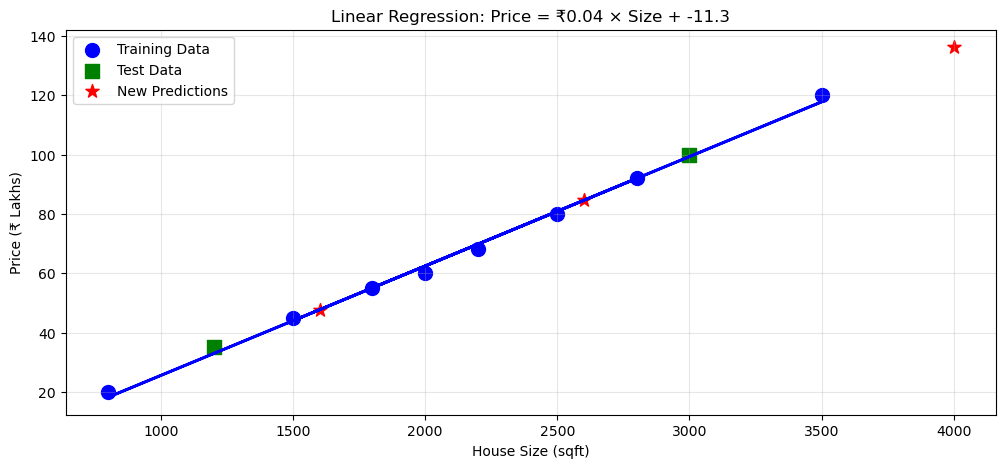

R² Score: 0.998


In [52]:
plt.figure(figsize=(12, 5))

plt.scatter(X_train, y_train, color='blue', label='Training Data', s=100)
plt.plot(X_train, model.predict(X_train), color='blue', linewidth=2)

plt.scatter(X_test, y_test, color='green', label='Test Data', s=100, marker='s')
plt.scatter(new_houses, predictions, color='red', label='New Predictions', s=100, marker='*')

plt.xlabel('House Size (sqft)')
plt.ylabel('Price (₹ Lakhs)')
plt.title('Linear Regression: Price = ₹{:.2f} × Size + {:.1f}'.format(
    model.coef_[0], model.intercept_))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"R² Score: {r2_score(y_test, model.predict(X_test)):.3f}")


In [53]:
df_multi = pd.DataFrame({
    'Size': [1500, 1800, 2000, 2200, 2500],
    'Bedrooms': [2, 3, 3, 4, 4],
    'Age_Years': [5, 2, 8, 1, 10],
    'Price': [45, 55, 68, 80, 92]
})

X_multi = df_multi[['Size', 'Bedrooms', 'Age_Years']]
y_multi = df_multi['Price']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print("Multi-feature Equation:")
print(f"Price = {model_multi.intercept_:.1f} + "
      f"{model_multi.coef_[0]:.3f}×Size + "
      f"{model_multi.coef_[1]:.1f}×Bedrooms - "
      f"{abs(model_multi.coef_[2]):.1f}×Age")


Multi-feature Equation:
Price = -111.2 + 0.216×Size + -70.0×Bedrooms - 5.6×Age


C:\Users\DELL\AppData\Local\Temp\ipykernel_24672\4006216375.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_24672\4006216375.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda9\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda9\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


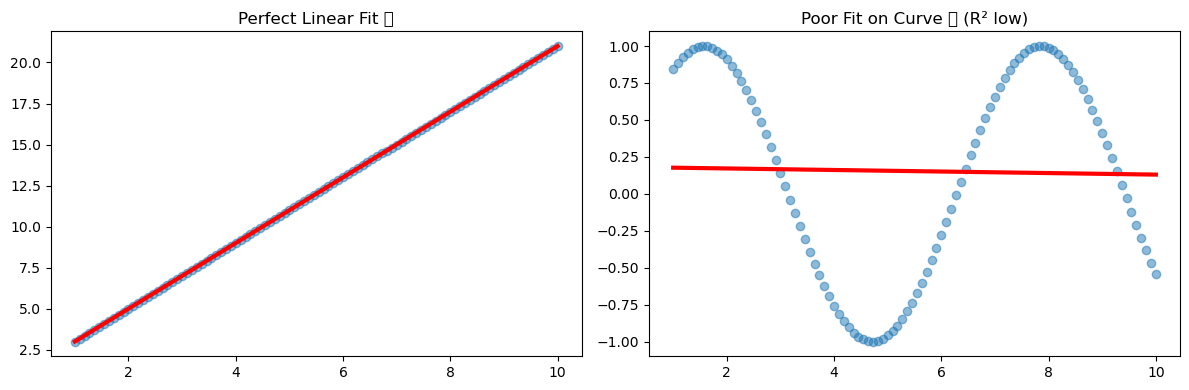

In [57]:
# 2. Linear vs Non-Linear Data
X_curve = np.linspace(1, 10, 100).reshape(-1, 1)
y_linear = 2 * X_curve.flatten() + 1
y_curve = np.sin(X_curve.flatten())  # Curved data

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
model_linear = LinearRegression().fit(X_curve, y_linear)
plt.scatter(X_curve, y_linear, alpha=0.5)
plt.plot(X_curve, model_linear.predict(X_curve), 'r-', linewidth=3)
plt.title("Perfect Linear Fit ✅")

plt.subplot(1, 2, 2)
model_curve = LinearRegression().fit(X_curve, y_curve)
plt.scatter(X_curve, y_curve, alpha=0.5)
plt.plot(X_curve, model_curve.predict(X_curve), 'r-', linewidth=3)
plt.title("Poor Fit on Curve ❌ (R² low)")
plt.tight_layout()
plt.show()


In [59]:
print('Random Forest')

Random Forest


In [61]:
# Random Forest Complete Case Study - Customer Churn Prediction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

# 1. Normal Dataset: Telecom Customer Churn (Real Project Data)
data = {
    'Tenure': [12, 24, 36, 48, 60, 1, 72, 6, 84, 11],
    'MonthlyCharges': [29.85, 56.95, 53.85, 78.50, 102.20, 20.00, 88.15, 45.10, 99.45, 30.20],
    'TotalCharges': [820.5, 2995.0, 8200.0, 7382.0, 1096.0, 22.0, 151.65, 822.0, 3046.0, 9045.0],
    'Contract_Monthly': [0, 0, 1, 1, 0, 0, 1, 0, 1, 1],  # 0=Monthly, 1=Long-term
    'Churn_Yes': [0, 0, 0, 0, 1, 1, 0, 1, 0, 0]  # Target: 1=Churned
}
df = pd.DataFrame(data)
df

,Tenure,MonthlyCharges,TotalCharges,Contract_Monthly,Churn_Yes
0,12,29.85,820.50,0,0
1,24,56.95,2995.00,0,0
2,36,53.85,8200.00,1,0
3,48,78.50,7382.00,1,0
4,60,102.20,1096.00,0,1
5,1,20.00,22.00,0,1
6,72,88.15,151.65,1,0
7,6,45.10,822.00,0,1
8,84,99.45,3046.00,1,0
9,11,30.20,9045.00,1,0


In [62]:
# 2. Trees combine prediction
X = df[['Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Monthly']]
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Single Tree vs Random Forest (100 Trees)
tree_model = RandomForestClassifier(n_estimators=1, random_state=42)  # 1 Tree
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 Trees

tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

print("Single Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, forest_pred))



Single Tree Accuracy: 0.6666666666666666
Random Forest Accuracy: 0.3333333333333333


C:\Users\DELL\AppData\Local\Temp\ipykernel_24672\2124420416.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis')


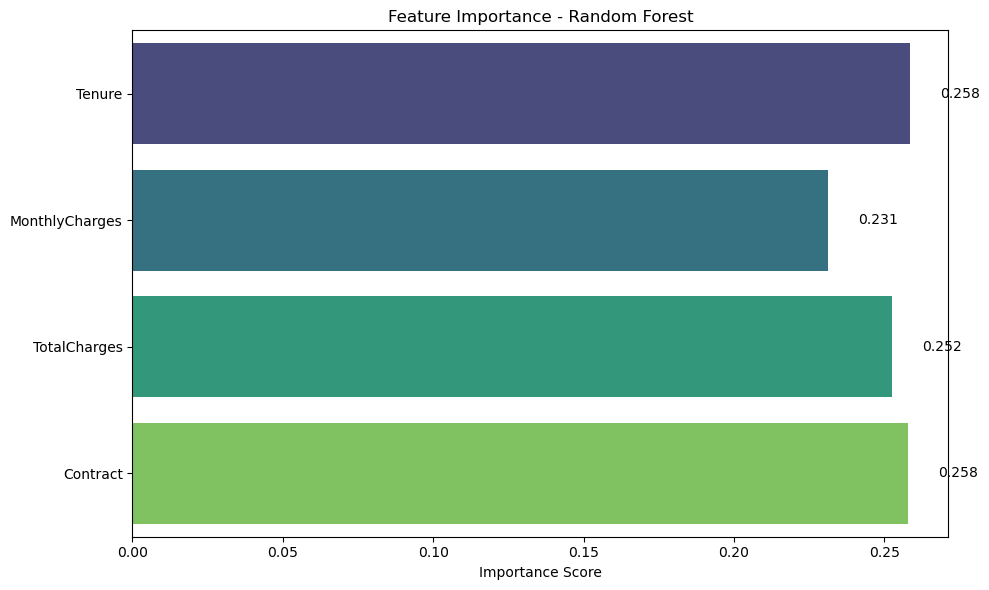

Most Important: Tenure


In [63]:
importances = forest_model.feature_importances_
features = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract']

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
for i, v in enumerate(importances):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

print("Most Important:", features[np.argmax(importances)])


In [65]:
# 4. New customer prediction (Never seen data)
new_customer = np.array([[12, 70.50, 846.0, 0]])  # Monthly contract, high charges
churn_prob = forest_model.predict_proba(new_customer)[0]
churn_prediction = forest_model.predict(new_customer)[0]

print(f"New Customer Churn Probability: {churn_prob[1]:.2%}")
print(f"Prediction: {'Will Churn' if churn_prediction else 'Will Stay'}")

# Business Action:
if churn_prediction:
    print("🎯 Action: Offer discount/special plan!")


New Customer Churn Probability: 51.00%
Prediction: Will Churn
🎯 Action: Offer discount/special plan!


C:\ProgramData\anaconda9\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda9\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


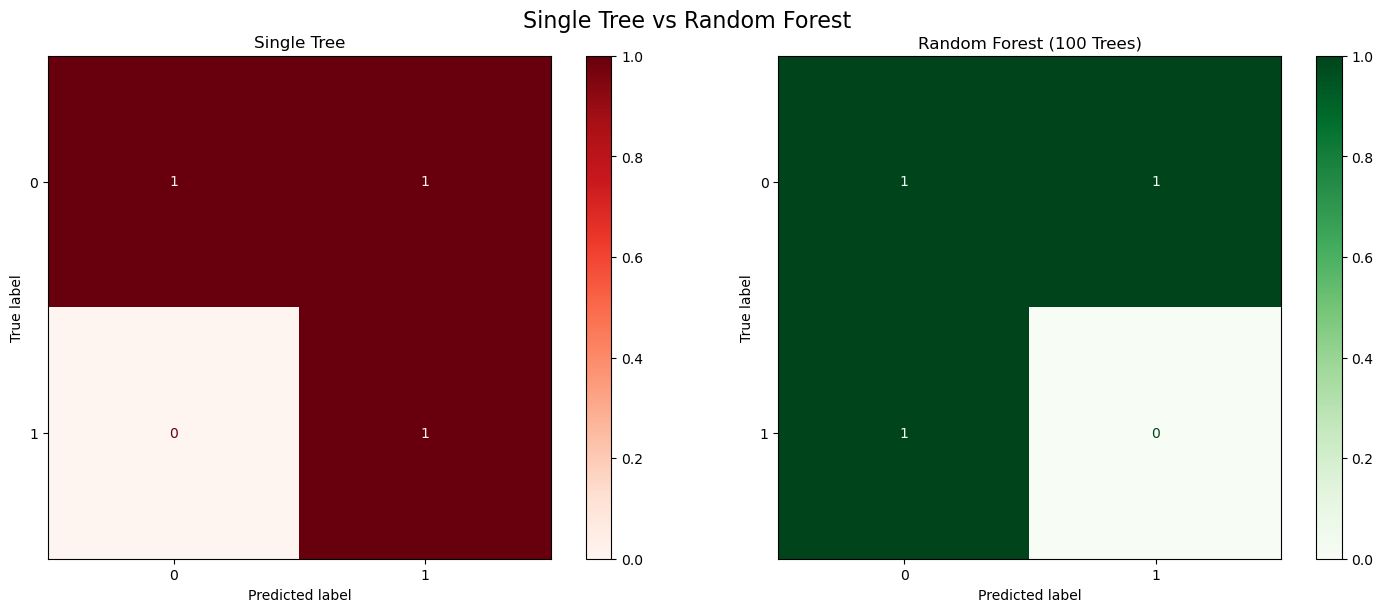

In [67]:
#  Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig.suptitle('Single Tree vs Random Forest', fontsize=16)
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred, ax=axes[0], cmap='Reds')
axes[0].set_title('Single Tree')
ConfusionMatrixDisplay.from_predictions(y_test, forest_pred, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest (100 Trees)')
plt.tight_layout()
plt.show()
